# ch292 — Dimensionality Reduction

*(Applies SVD from ch173 and PCA intuition from ch174; uses covariance from ch273)*

## 1. The Curse of Dimensionality

In high-dimensional spaces, every point is far from every other point. Data becomes sparse. Distances lose meaning. Models require exponentially more samples to generalize.

Dimensionality reduction finds a lower-dimensional representation that preserves the structure relevant to your task.

---

## 2. PCA from Scratch

Explained variance ratio (manual): [0.5416 0.4239]
Explained variance ratio (sklearn): [0.5416 0.4239]
Match (up to sign): True


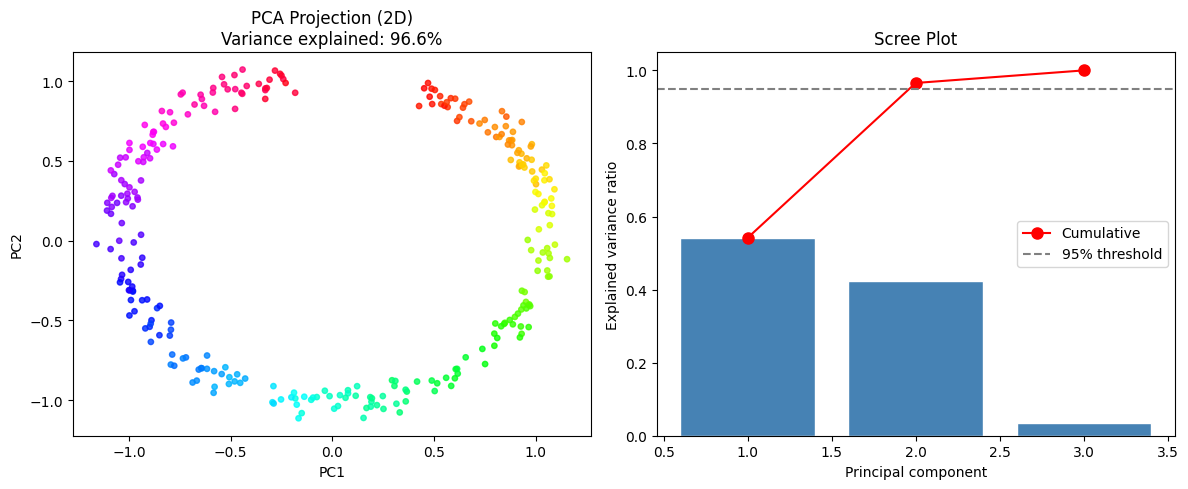

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA as sklearn_PCA
from sklearn.datasets import load_digits


class PCA:
    """
    Principal Component Analysis via eigendecomposition of the covariance matrix.
    Numerically, uses SVD for stability (equivalent, more robust).
    """
    def __init__(self, n_components: int):
        self.n_components = n_components
        self.components_   = None  # principal components (rows)
        self.explained_variance_ratio_ = None
        self.mean_          = None

    def fit(self, X: np.ndarray) -> 'PCA':
        self.mean_ = X.mean(axis=0)
        X_c        = X - self.mean_
        # SVD: X_c = U @ S @ Vt
        # Principal components are rows of Vt
        _, S, Vt = np.linalg.svd(X_c, full_matrices=False)
        self.components_ = Vt[:self.n_components]
        # Explained variance from singular values
        explained_var = (S**2) / (len(X) - 1)
        self.explained_variance_ratio_ = (
            explained_var[:self.n_components] / explained_var.sum()
        )
        self._singular_values = S
        return self

    def transform(self, X: np.ndarray) -> np.ndarray:
        return (X - self.mean_) @ self.components_.T

    def fit_transform(self, X: np.ndarray) -> np.ndarray:
        return self.fit(X).transform(X)

    def inverse_transform(self, X_reduced: np.ndarray) -> np.ndarray:
        return X_reduced @ self.components_ + self.mean_


# Generate 3D data with intrinsic 2D structure
rng = np.random.default_rng(42)
n   = 300
t   = rng.uniform(0, 2*np.pi, n)
X_3d = np.column_stack([
    np.cos(t) + rng.normal(0, 0.05, n),
    np.sin(t) + rng.normal(0, 0.05, n),
    0.2 * t   + rng.normal(0, 0.05, n),
])

pca = PCA(n_components=2)
X_2d = pca.fit_transform(X_3d)

# Validate against sklearn
pca_sk = sklearn_PCA(n_components=2)
X_2d_sk = pca_sk.fit_transform(X_3d)

print("Explained variance ratio (manual):",
      np.round(pca.explained_variance_ratio_, 4))
print("Explained variance ratio (sklearn):",
      np.round(pca_sk.explained_variance_ratio_, 4))
print("Match (up to sign):",
      np.allclose(np.abs(X_2d), np.abs(X_2d_sk), atol=1e-8))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ax = axes[0]
ax.scatter(X_2d[:, 0], X_2d[:, 1], c=t, cmap='hsv', s=15, alpha=0.8)
ax.set_title(f'PCA Projection (2D)\n'
             f'Variance explained: {pca.explained_variance_ratio_.sum():.1%}')
ax.set_xlabel('PC1'); ax.set_ylabel('PC2')

# Scree plot
pca_full = PCA(n_components=3).fit(X_3d)
ax = axes[1]
explained = (pca_full._singular_values**2) / (pca_full._singular_values**2).sum()
ax.bar(range(1, 4), explained, color='steelblue', edgecolor='white')
ax.plot(range(1, 4), np.cumsum(explained), 'ro-', ms=8, label='Cumulative')
ax.axhline(0.95, color='gray', ls='--', label='95% threshold')
ax.set_xlabel('Principal component')
ax.set_ylabel('Explained variance ratio')
ax.set_title('Scree Plot')
ax.legend()

plt.tight_layout()
plt.show()

## 3. PCA for Reconstruction and Compression

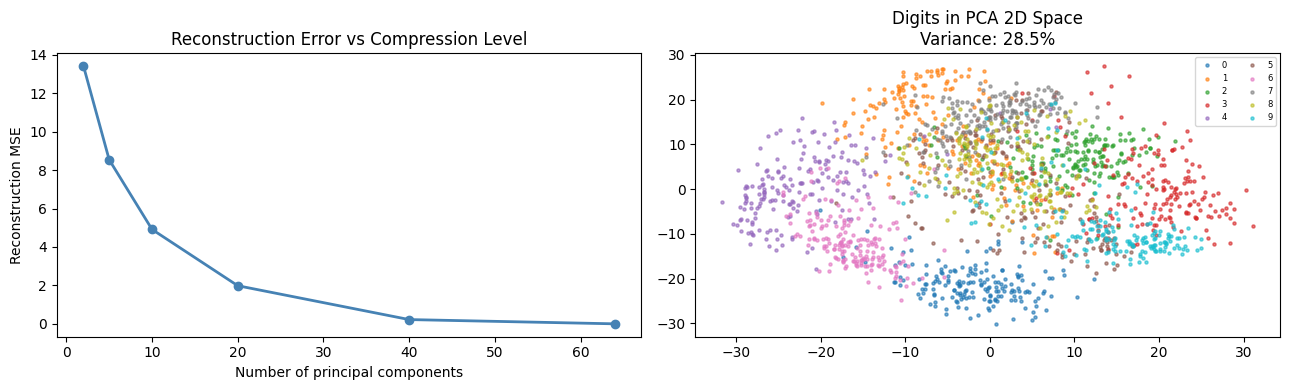

Original: (1797, 64) = 898 KB
After PCA (k=40): (1797, 40) = 561 KB
Compression ratio: 1.6x


In [2]:
# Apply PCA to handwritten digits
digits = load_digits()
X_digits = digits.data       # 1797 x 64
y_digits = digits.target

pca_dig = PCA(n_components=40)
X_reduced = pca_dig.fit_transform(X_digits)
X_reconstructed = pca_dig.inverse_transform(X_reduced)

# Show compression effect
n_comps   = [2, 5, 10, 20, 40, 64]
rec_errors = []
for k in n_comps:
    pk    = PCA(n_components=min(k, 64))
    Xr    = pk.fit_transform(X_digits)
    Xrec  = pk.inverse_transform(Xr)
    err   = np.mean((X_digits - Xrec)**2)
    rec_errors.append(err)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Reconstruction at different k
ax = axes[0]
ax.plot(n_comps, rec_errors, 'o-', color='steelblue', lw=2)
ax.set_xlabel('Number of principal components')
ax.set_ylabel('Reconstruction MSE')
ax.set_title('Reconstruction Error vs Compression Level')

# 2D projection of digits
pca2 = PCA(n_components=2)
X_2d_digits = pca2.fit_transform(X_digits)

ax = axes[1]
for digit in range(10):
    mask = y_digits == digit
    ax.scatter(X_2d_digits[mask, 0], X_2d_digits[mask, 1],
               s=5, alpha=0.6, label=str(digit))
ax.set_title('Digits in PCA 2D Space\n'
             f'Variance: {pca2.explained_variance_ratio_.sum():.1%}')
ax.legend(fontsize=6, ncol=2)

plt.tight_layout()
plt.show()

print(f"Original: {X_digits.shape} = {X_digits.nbytes // 1024} KB")
print(f"After PCA (k=40): {X_reduced.shape} = {X_reduced.nbytes // 1024} KB")
print(f"Compression ratio: {X_digits.nbytes / X_reduced.nbytes:.1f}x")

## 4. t-SNE: Non-Linear Dimensionality Reduction (Concept)

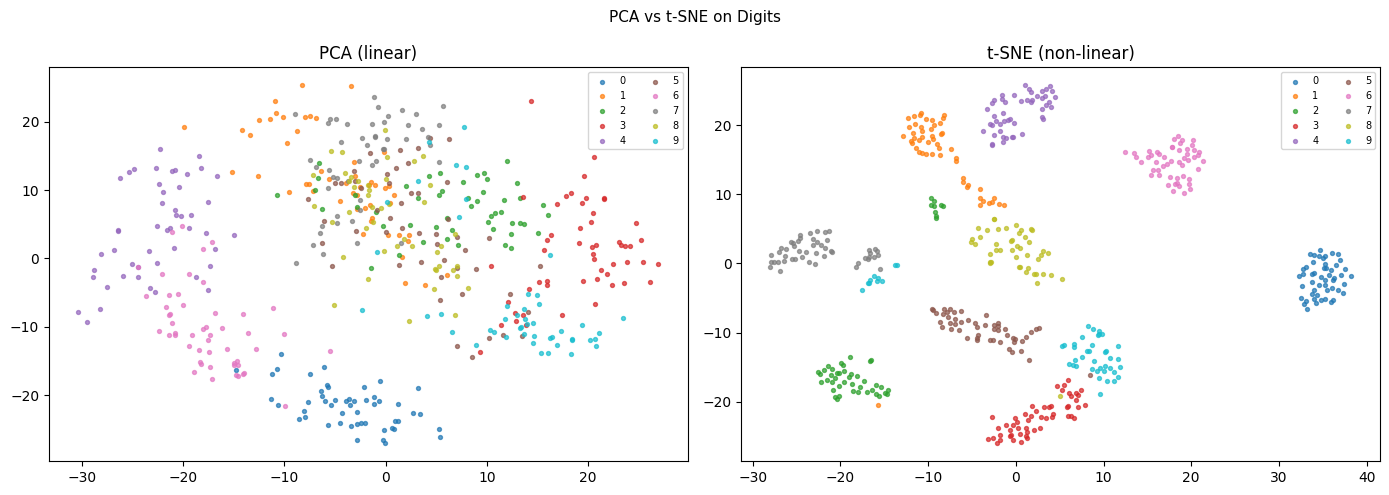

PCA: preserves global structure, linear, fast, deterministic.
t-SNE: preserves local clusters, non-linear, slow, non-deterministic.
Use PCA for compression/preprocessing; t-SNE for visualization.


In [5]:
# t-SNE is non-linear and preserves local structure.
# Full implementation is complex; we show the core idea and use sklearn.
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_tsne = tsne.fit_transform(X_digits[:500])  # subset for speed
y_sub  = y_digits[:500]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (X_2d, title) in zip(axes, [
    (pca2.transform(X_digits[:500]),  'PCA (linear)'),
    (X_tsne,                           't-SNE (non-linear)'),
]):
    for digit in range(10):
        mask = y_sub == digit
        ax.scatter(X_2d[mask, 0], X_2d[mask, 1], s=8, alpha=0.7, label=str(digit))
    ax.set_title(title)
    ax.legend(fontsize=7, ncol=2)

plt.suptitle('PCA vs t-SNE on Digits', fontsize=11)
plt.tight_layout()
plt.show()

print("PCA: preserves global structure, linear, fast, deterministic.")
print("t-SNE: preserves local clusters, non-linear, slow, non-deterministic.")
print("Use PCA for compression/preprocessing; t-SNE for visualization.")

## 5. What Comes Next

PCA is unsupervised — it finds directions of maximum variance without using labels. **ch293 — Clustering** is also unsupervised and finds group structure in data. **ch294 — Classification** is supervised and uses labels to find decision boundaries. The 2D PCA projections here make the class structure visible — a direct preview of what classifiers will formalize.